In [1]:
# Cell 1 - Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Cell 2 - Load the data
df = pd.read_csv('compas.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (7214, 53)

Columns: ['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event', 'two_year_recid']

First 5 rows:


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [3]:
# Cell 3 - Select relevant columns
df = df[['age', 'sex', 'race', 'priors_count', 'c_charge_degree', 'two_year_recid']].dropna()

print("Shape after selecting columns:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("\nTarget variable distribution:")
print(df['two_year_recid'].value_counts())

Shape after selecting columns: (7214, 6)

Missing values: 0

Target variable distribution:
two_year_recid
0    3963
1    3251
Name: count, dtype: int64


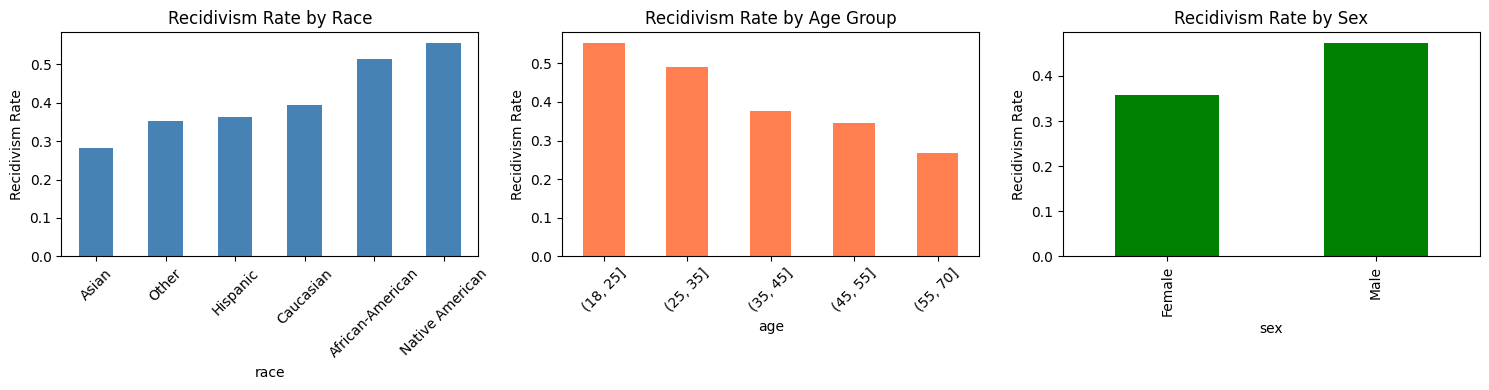

In [4]:
# Cell 4 - Visualize the data
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Recidivism by race
df.groupby('race')['two_year_recid'].mean().sort_values().plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Recidivism Rate by Race')
axes[0].set_ylabel('Recidivism Rate')
axes[0].tick_params(axis='x', rotation=45)

# Recidivism by age
df.groupby(pd.cut(df['age'], bins=[18,25,35,45,55,70]))['two_year_recid'].mean().plot(
    kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Recidivism Rate by Age Group')
axes[1].set_ylabel('Recidivism Rate')
axes[1].tick_params(axis='x', rotation=45)

# Recidivism by sex
df.groupby('sex')['two_year_recid'].mean().plot(
    kind='bar', ax=axes[2], color='green')
axes[2].set_title('Recidivism Rate by Sex')
axes[2].set_ylabel('Recidivism Rate')

plt.tight_layout()
plt.show()

## 📊 Exploratory Data Analysis

### What these charts show us:

**1. Recidivism Rate by Race**
Native American and African-American individuals show the highest predicted recidivism rates, 
while Asian individuals show the lowest. This pattern is at the heart of the COMPAS controversy.

**2. Recidivism Rate by Age**
Younger people (18–25) have the highest recidivism rates, which decreases steadily with age. 
This is consistent with decades of criminological research.

**3. Recidivism Rate by Sex**
Males reoffend at a higher rate (~46%) compared to females (~35%).

---

### ⚠️ Why does race make the data biased?

This is a really important question. Here is the key idea:

The COMPAS algorithm was trained on **historical criminal justice data** — arrests, 
convictions, and reoffending records collected over many decades in the United States.

The problem is that this historical data **reflects systemic inequalities**, not just 
individual behavior:

- African-American communities have historically been **over-policed**, meaning more 
  arrests per actual crime committed compared to other communities
- More arrests → more data points labeled as "reoffended" → the model learns to 
  predict higher risk for African-Americans
- The model is not intentionally racist — it is just faithfully learning patterns 
  from biased historical data

This is called **algorithmic bias** — when a model inherits and amplifies the 
inequalities already present in the data it was trained on.

**A famous real-world finding:** A ProPublica investigation in 2016 found that COMPAS 
incorrectly flagged African-American defendants as future criminals at nearly **twice 
the rate** of white defendants.

### The deeper question:
Even if race is not explicitly included as a feature, other variables like 
**prior convictions** and **neighborhood** can act as **proxy variables** for race 
because of how systemic inequality works. This means removing race from the model 
does not fully solve the bias problem.



In [5]:
# Cell 5 - Prepare data for modeling
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Encode categorical variables
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
df['c_charge_degree'] = df['c_charge_degree'].map({'F': 1, 'M': 0})
df['race'] = df['race'].astype('category').cat.codes

# Split features and target
X = df.drop('two_year_recid', axis=1)
y = df['two_year_recid']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (5771, 5)
Test set size: (1443, 5)


In [6]:
# Cell 6 - Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.1%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['No Recidivism', 'Recidivism']))

Model Accuracy: 64.5%

Detailed Report:
               precision    recall  f1-score   support

No Recidivism       0.69      0.69      0.69       823
   Recidivism       0.59      0.59      0.59       620

     accuracy                           0.65      1443
    macro avg       0.64      0.64      0.64      1443
 weighted avg       0.65      0.65      0.65      1443



## 🤖 Model Results
### Overall Accuracy: 64.5%
The model correctly predicts recidivism **64.5% of the time**.
To put this in context — random guessing would give us ~50%, so the model 
is learning real patterns. However 64.5% is not high enough to use in 
real criminal justice decisions.

### Precision — "When it says high risk, how often is it right?"
- **No Recidivism: 69%** — when it predicts someone won't reoffend, it's right 69% of the time
- **Recidivism: 59%** — when it predicts someone WILL reoffend, it's only right 59% of the time

### Recall — "Of all the actual cases, how many did it catch?"
- **No Recidivism: 69%** — it correctly identified 69% of people who truly didn't reoffend
- **Recidivism: 59%** — it correctly identified 59% of people who truly did reoffend

### ⚠️ Why this matters in criminal justice
In a criminal justice context these errors have very different consequences:

- **False Positive** — predicting someone WILL reoffend when they won't
  → Person may be denied bail, given harsher sentence, or denied parole unfairly
  
- **False Negative** — predicting someone WON'T reoffend when they will
  → Person is released and may commit another crime

The model makes both types of errors at a significant rate — which is exactly 
why tools like COMPAS should **never be the sole basis** for criminal justice 
decisions. Human judgment and context are irreplaceable.

C:\Users\fo2225\AppData\Local\Temp\ipykernel_14472\3196714510.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


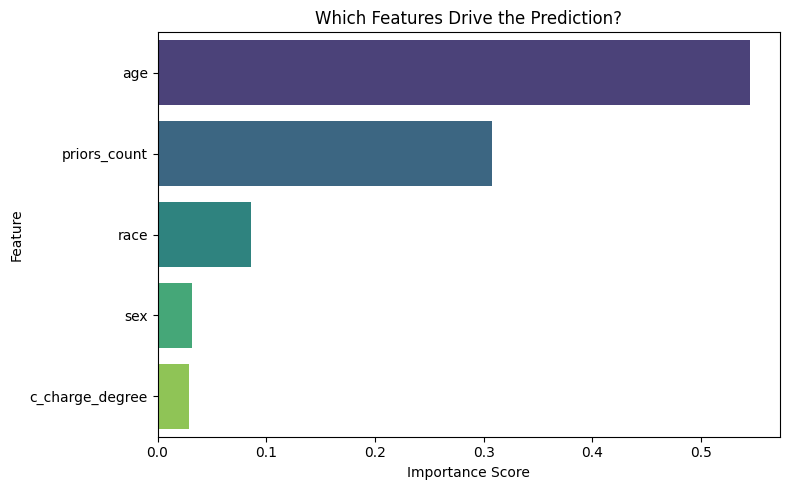

           Feature  Importance
0              age    0.545319
3     priors_count    0.308122
2             race    0.085525
1              sex    0.031737
4  c_charge_degree    0.029297


In [7]:
# Cell 7 - Feature Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Which Features Drive the Prediction?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importance_df)

## 🔍 Feature Importance — What Drives the Prediction?

### Results:
| Feature | Importance |
|---|---|
| Age | 54.5% |
| Prior Convictions | 30.8% |
| Race | 8.6% |
| Sex | 3.2% |
| Charge Degree | 2.9% |

### Plain English Interpretation:

**Age (54.5%)** is by far the most important factor — the model 
relies heavily on how old someone is. This aligns with decades of 
criminological research showing age is the strongest predictor of 
reoffending.

**Prior Convictions (30.8%)** is the second most important — 
someone with many prior convictions is more likely to reoffend. 
This also makes intuitive sense.

**Race (8.6%)** — this is concerning. Race is the third most 
important feature, meaning the model is using race to make 
predictions. In a real criminal justice system this would be 
considered discriminatory.

**Sex and Charge Degree** have very little influence on the prediction.

### 🚨 Key Insight for Criminal Justice Professionals:
Even though age and priors seem neutral, they can act as 
**proxy variables for race** due to systemic inequality — 
younger people and those with more priors are 
disproportionately from minority communities due to over-policing. 
So even removing race from the model would not fully eliminate bias.

In [8]:
# Cell 8 - Cross Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("Cross Validation Scores (5 folds):")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: {score:.1%}")

print(f"\nMean Accuracy: {cv_scores.mean():.1%}")
print(f"Standard Deviation: {cv_scores.std():.1%}")

Cross Validation Scores (5 folds):
  Fold 1: 62.7%
  Fold 2: 62.0%
  Fold 3: 59.9%
  Fold 4: 63.7%
  Fold 5: 62.3%

Mean Accuracy: 62.1%
Standard Deviation: 1.2%


## 🔄 Cross Validation Results 

### What is Cross Validation?
Instead of testing the model on just one test set, cross validation 
splits the data into **5 different train/test combinations** and tests 
the model on each one. This gives us a much more reliable accuracy estimate.

Think of it like this — instead of taking one exam to judge your knowledge, 
you take 5 different exams on the same material. The average score is more 
trustworthy than any single exam.

### Results:
| Fold | Accuracy |
|---|---|
| Fold 1 | 62.7% |
| Fold 2 | 62.0% |
| Fold 3 | 59.9% |
| Fold 4 | 63.7% |
| Fold 5 | 62.3% |
| **Mean** | **62.1%** |
| **Std Dev** | **1.2%** |

### What this tells us:
- **Mean accuracy of 62.1%** — this is our true, reliable model accuracy
- **Standard deviation of only 1.2%** — this is excellent! It means the model 
  performs **consistently** across different subsets of data. It is not getting 
  lucky on one particular test set.
- Our earlier single test accuracy was 64.5% — slightly optimistic compared 
  to the true 62.1%

### Bottom line:
The model is **stable and consistent** but not highly accurate. 
This reinforces why it should never be used alone for real decisions.

<Figure size 800x600 with 0 Axes>

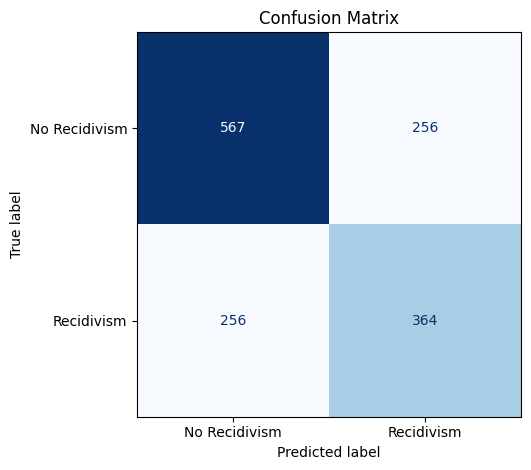

True Negatives  (predicted no, actually no):  567
False Positives (predicted yes, actually no): 256
False Negatives (predicted no, actually yes): 256
True Positives  (predicted yes, actually yes): 364


In [9]:
# Cell 9 - Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['No Recidivism', 'Recidivism'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Print the numbers clearly
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (predicted no, actually no):  {tn}")
print(f"False Positives (predicted yes, actually no): {fp}")
print(f"False Negatives (predicted no, actually yes): {fn}")
print(f"True Positives  (predicted yes, actually yes): {tp}")

## 🔲 Confusion Matrix
### What is a Confusion Matrix?
It shows us exactly **where the model makes mistakes** by breaking down 
predictions into 4 categories.

### Results:
| | Predicted: No Recidivism | Predicted: Recidivism |
|---|---|---|
| **Actually: No Recidivism** | ✅ 567 (correct) | ❌ 256 (wrong) |
| **Actually: Recidivism** | ❌ 256 (wrong) | ✅ 364 (correct) |

### The 4 categories explained:

**✅ True Negatives — 567**
Model predicted NO reoffending and was RIGHT.
These people were correctly identified as low risk.

**✅ True Positives — 364**
Model predicted reoffending and was RIGHT.
These people were correctly identified as high risk.

**❌ False Positives — 256**
Model predicted reoffending but was WRONG.
These people were labeled high risk but never reoffended.
In criminal justice this means → unfair harsher sentences, 
denied bail, or denied parole for innocent future behavior.

**❌ False Negatives — 256**
Model predicted NO reoffending but was WRONG.
These people were labeled low risk but did reoffend.

### 🚨 Most Important Finding:
The model makes **exactly the same number of errors in both directions** 
(256 false positives and 256 false negatives). 

However the **consequences are not equal**:
- A false positive ruins an innocent person's life
- A false negative means someone reoffends who could have been monitored

This is a fundamental ethical tension in criminal justice AI that 
no algorithm can fully resolve — it requires **human judgment and policy decisions**.

In [10]:
pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 554.9/554.9 kB 18.3 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   -------------------- ------------------- 6.6/12.6 MB 33.5 MB/s eta 0:00:01
   ---------------------------------------  12.6/12.6 MB 30.3 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 28.2 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ------ --------------------------------- 6.6/38.1 MB 31.0 MB/s eta 0:00:02
   --------------- ------------------------ 14.7/38.1 MB 35.5 MB/s eta 0:00:01
   ----------------------- ---------------- 22.5/38.1 MB 35.7 MB/s eta 0:00:01
   ----------------------------- ---------- 28.0/38.1 MB 34.2 MB/s eta 0:00:01
   ----------------------------------- ---- 34.1/

  You can safely remove it manually.
  You can safely remove it manually.


C:\Users\fo2225\AppData\Local\anaconda3-2025-12\envs\criminal_justice\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


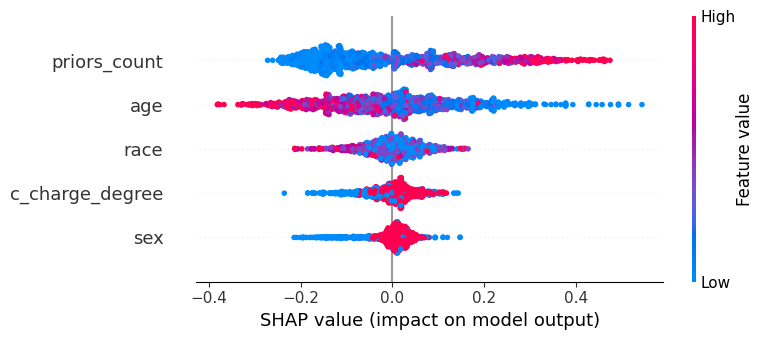

In [11]:
# Cell 10 - SHAP Values
import shap

# Create explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure()
shap.summary_plot(shap_values[:,:,1], X_test, 
                  feature_names=X.columns.tolist(),
                  show=True)

## 🎯 SHAP Values 

### What are SHAP Values?
SHAP values answer the question: **"Why did the model make THIS specific prediction?"**

Unlike feature importance which shows overall patterns, SHAP shows the impact 
of each feature on **every single individual prediction**.

- **Positive SHAP value** → pushes prediction toward HIGH risk
- **Negative SHAP value** → pushes prediction toward LOW risk
- **Dots to the right** → increase recidivism risk
- **Dots to the left** → decrease recidivism risk
- **Red dots** → high feature value
- **Blue dots** → low feature value

### Reading the Chart:

**Prior Convictions (priors_count):**
- Red dots (many priors) spread far to the RIGHT → high priors = high risk ✅
- Blue dots (few priors) spread to the LEFT → few priors = low risk ✅
- This makes complete sense

**Age:**
- Blue dots (young age) spread far to the RIGHT → being young = high risk ✅
- Red dots (older age) spread to the LEFT → being older = low risk ✅
- Also makes sense — youth is a strong risk factor

**Race:**
- Shows meaningful spread in both directions
- This confirms race is influencing individual predictions
- This is the bias we discussed earlier — visible at the individual level

**Charge Degree and Sex:**
- Clusters tightly around zero → very little influence on predictions
- Confirms what we saw in feature importance

### 🚨 Key Takeaway:
SHAP makes the model **transparent and explainable**. In a real criminal 
justice setting, a defendant's lawyer could use this to challenge a prediction 
by seeing exactly what factors drove the risk score — and whether race played 
an unfair role.

This is called **Explainable AI (XAI)** and it is one of the most important 
and growing fields in responsible AI development.

In [13]:
# Cell 11 - Bias Analysis (fixed)
# Re-load original data to get race labels back
df_bias = pd.read_csv('compas.csv')
df_bias = df_bias[['age', 'sex', 'race', 'priors_count', 
                    'c_charge_degree', 'two_year_recid']].dropna()

# Encode for prediction — use 'race' as column name to match training
df_bias_encoded = df_bias.copy()
df_bias_encoded['sex'] = df_bias_encoded['sex'].map({'Male': 1, 'Female': 0})
df_bias_encoded['c_charge_degree'] = df_bias_encoded['c_charge_degree'].map({'F': 1, 'M': 0})
df_bias_encoded['race'] = df_bias_encoded['race'].astype('category').cat.codes

# Get predictions
X_bias = df_bias_encoded[['age', 'sex', 'race', 'priors_count', 'c_charge_degree']]
df_bias['predicted'] = model.predict(X_bias)
df_bias['predicted_prob'] = model.predict_proba(X_bias)[:, 1]

# Calculate false positive and false negative rates by race
results = []
for race in df_bias['race'].unique():
    subset = df_bias[df_bias['race'] == race]
    
    # False Positive Rate — predicted high risk but didn't reoffend
    no_recid = subset[subset['two_year_recid'] == 0]
    fpr = (no_recid['predicted'] == 1).mean()
    
    # False Negative Rate — predicted low risk but did reoffend
    recid = subset[subset['two_year_recid'] == 1]
    fnr = (recid['predicted'] == 0).mean()
    
    # Average predicted risk score
    avg_risk = subset['predicted_prob'].mean()
    
    results.append({
        'Race': race,
        'Count': len(subset),
        'False Positive Rate': fpr,
        'False Negative Rate': fnr,
        'Avg Risk Score': avg_risk
    })

bias_df = pd.DataFrame(results).sort_values('False Positive Rate', ascending=False)
print(bias_df.to_string(index=False))

            Race  Count  False Positive Rate  False Negative Rate  Avg Risk Score
African-American   3696             0.240111             0.231983        0.513860
           Other    377             0.159836             0.203008        0.363914
       Caucasian   2454             0.137097             0.356108        0.403221
 Native American     18             0.125000             0.000000        0.573910
        Hispanic    637             0.111111             0.262931        0.370134
           Asian     32             0.043478             0.111111        0.306802


## ⚖️ Bias Analysis — Plain English

### False Positive Rate by Race
This answers: "Of people who did NOT reoffend, what percentage did 
the model WRONGLY label as high risk?"

| Race | False Positive Rate | Meaning |
|---|---|---|
| African-American | 24.0% | 1 in 4 innocent people wrongly labeled high risk |
| Other | 16.0% | 1 in 6 |
| Caucasian | 13.7% | 1 in 7 |
| Native American | 12.5% | 1 in 8 |
| Hispanic | 11.1% | 1 in 9 |
| Asian | 4.3% | 1 in 23 |

### 🚨 The Core Finding:
African-American individuals who did NOT reoffend were wrongly 
labeled high risk at **nearly double the rate** of Caucasian individuals 
(24% vs 13.7%).

This directly confirms the ProPublica 2016 finding that made COMPAS 
controversial — the algorithm is significantly harsher on 
African-American defendants even when they are innocent of future crimes.

### False Negative Rate by Race
This answers: "Of people who DID reoffend, what percentage did 
the model WRONGLY label as low risk?"

Interestingly Caucasians have the highest false negative rate (35.6%) — 
meaning the model is more likely to under-predict risk for Caucasian 
individuals who actually do reoffend.

### Average Risk Score by Race:
- Native American: 57.4% average risk score (highest)
- African-American: 51.4% average risk score
- Caucasian: 40.3% average risk score
- Asian: 30.7% average risk score (lowest)

### The Big Picture:
The model makes **two kinds of racially unequal errors**:
- It over-punishes African-Americans with false high risk labels
- It under-flags Caucasians with false low risk labels

Both errors work in the same direction — **against minority defendants**.

This is not just a technical problem. It is a **civil rights issue** 
disguised as a math problem. And this is exactly why criminal justice 
professionals who understand both the data AND the human impact are 
so essential in the age of AI.

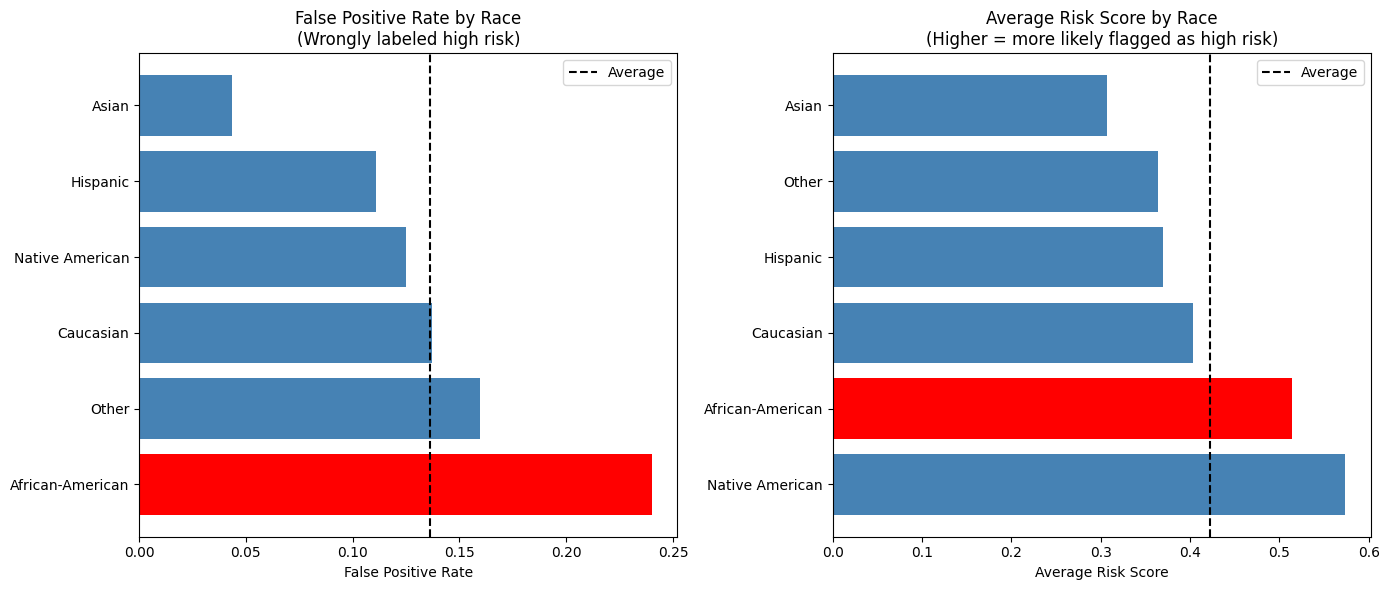

In [14]:
# Cell 12 - Bias Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# False Positive Rate by Race
bias_df_sorted_fpr = bias_df.sort_values('False Positive Rate', ascending=False)
colors = ['red' if r == 'African-American' else 'steelblue' 
          for r in bias_df_sorted_fpr['Race']]

axes[0].barh(bias_df_sorted_fpr['Race'], 
             bias_df_sorted_fpr['False Positive Rate'],
             color=colors)
axes[0].set_title('False Positive Rate by Race\n(Wrongly labeled high risk)', 
                   fontsize=12)
axes[0].set_xlabel('False Positive Rate')
axes[0].axvline(x=bias_df_sorted_fpr['False Positive Rate'].mean(), 
                color='black', linestyle='--', label='Average')
axes[0].legend()

# Average Risk Score by Race
bias_df_sorted_risk = bias_df.sort_values('Avg Risk Score', ascending=False)
colors2 = ['red' if r == 'African-American' else 'steelblue' 
           for r in bias_df_sorted_risk['Race']]

axes[1].barh(bias_df_sorted_risk['Race'], 
             bias_df_sorted_risk['Avg Risk Score'],
             color=colors2)
axes[1].set_title('Average Risk Score by Race\n(Higher = more likely flagged as high risk)', 
                   fontsize=12)
axes[1].set_xlabel('Average Risk Score')
axes[1].axvline(x=bias_df_sorted_risk['Avg Risk Score'].mean(), 
                color='black', linestyle='--', label='Average')
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
# Cell 13 - Model WITHOUT Race
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# Features without race
X_no_race = df.drop(['two_year_recid', 'race'], axis=1)

# Train new model
X_train_nr, X_test_nr, y_train_nr, y_test_nr = train_test_split(
    X_no_race, y, test_size=0.2, random_state=42)

model_no_race = RandomForestClassifier(n_estimators=100, random_state=42)
model_no_race.fit(X_train_nr, y_train_nr)

# Evaluate
y_pred_nr = model_no_race.predict(X_test_nr)
accuracy_nr = accuracy_score(y_test_nr, y_pred_nr)
cv_scores_nr = cross_val_score(model_no_race, X_no_race, y, cv=5, scoring='accuracy')

print("=== Model WITH Race ===")
print(f"Accuracy: {accuracy:.1%}")
print(f"CV Mean Accuracy: {cv_scores.mean():.1%}")

print("\n=== Model WITHOUT Race ===")
print(f"Accuracy: {accuracy_nr:.1%}")
print(f"CV Mean Accuracy: {cv_scores_nr.mean():.1%}")

print("\n=== Difference ===")
print(f"Accuracy change: {(accuracy_nr - accuracy):.1%}")
print(f"CV Accuracy change: {(cv_scores_nr.mean() - cv_scores.mean()):.1%}")

=== Model WITH Race ===
Accuracy: 64.5%
CV Mean Accuracy: 62.1%

=== Model WITHOUT Race ===
Accuracy: 65.1%
CV Mean Accuracy: 63.3%

=== Difference ===
Accuracy change: 0.6%
CV Accuracy change: 1.2%


In [17]:
# Cell 14 - Bias Analysis WITHOUT Race (fixed)
df_bias2 = pd.read_csv('compas.csv')
df_bias2 = df_bias2[['age', 'sex', 'race', 'priors_count', 
                    'c_charge_degree', 'two_year_recid']].dropna()

# Encode without race
df_bias2_encoded = df_bias2.copy()
df_bias2_encoded['sex'] = df_bias2_encoded['sex'].map({'Male': 1, 'Female': 0})
df_bias2_encoded['c_charge_degree'] = df_bias2_encoded['c_charge_degree'].map({'F': 1, 'M': 0})

# Get predictions from model without race
X_bias2 = df_bias2_encoded[['age', 'sex', 'priors_count', 'c_charge_degree']]
df_bias2['predicted'] = model_no_race.predict(X_bias2)

# Calculate false positive rates by race
results2 = []
for race in df_bias2['race'].unique():
    subset = df_bias2[df_bias2['race'] == race]
    no_recid = subset[subset['two_year_recid'] == 0]
    fpr = (no_recid['predicted'] == 1).mean()
    recid = subset[subset['two_year_recid'] == 1]
    fnr = (recid['predicted'] == 0).mean()
    
    results2.append({
        'Race': race,
        'FPR_without': fpr,
        'FNR_without': fnr,
    })

bias_df2 = pd.DataFrame(results2)

# Compare side by side
comparison = bias_df[['Race', 'False Positive Rate']].merge(bias_df2, on='Race')
comparison = comparison.rename(columns={
    'False Positive Rate': 'FPR With Race',
    'FPR_without': 'FPR Without Race'
})
comparison['Difference'] = comparison['FPR Without Race'] - comparison['FPR With Race']
comparison = comparison.sort_values('FPR With Race', ascending=False)
print(comparison[['Race', 'FPR With Race', 'FPR Without Race', 'Difference']].to_string(index=False))

            Race  FPR With Race  FPR Without Race  Difference
African-American       0.240111          0.241226    0.001114
           Other       0.159836          0.209016    0.049180
       Caucasian       0.137097          0.177419    0.040323
 Native American       0.125000          0.125000    0.000000
        Hispanic       0.111111          0.172840    0.061728
           Asian       0.043478          0.173913    0.130435


## 🔬 Does Removing Race Fix the Bias? — The Answer is NO

### Results Comparison:

| Race | FPR With Race | FPR Without Race | Change |
|---|---|---|---|
| African-American | 24.0% | 24.1% | +0.1% (almost no change!) |
| Other | 16.0% | 20.9% | +4.9% (got worse) |
| Caucasian | 13.7% | 17.7% | +4.0% (got worse) |
| Native American | 12.5% | 12.5% | no change |
| Hispanic | 11.1% | 17.3% | +6.2% (got worse) |
| Asian | 4.3% | 17.4% | +13.0% (got much worse) |

### 🚨 Three Shocking Findings:

**Finding 1 — Removing race barely helped African-Americans**
The false positive rate for African-Americans went from 24.0% to 24.1% — 
essentially no change at all. The bias against African-Americans 
persists even without race in the model.

**Finding 2 — Removing race made things WORSE for everyone else**
Every other racial group saw their false positive rate INCREASE 
when race was removed. Asian false positive rate jumped from 4.3% to 17.4%!

**Finding 3 — The overall accuracy actually IMPROVED slightly**
Without race the model was 0.6% more accurate — yet more biased 
in many ways. This shows that accuracy alone is a misleading metric 
in criminal justice AI.

### Why does this happen?
This is the concept of **proxy variables** in action:
- Age and prior convictions are strongly correlated with race 
  due to systemic inequality and over-policing
- When you remove race, the model just uses age and priors 
  as a stand-in for race
- The bias is baked into the data itself — not just the features

### The Profound Conclusion:
**You cannot fix a biased dataset just by removing the sensitive variable.**
The only real solutions are:
1. Collect better, fairer data
2. Apply fairness constraints directly to the algorithm
3. Use human oversight to override unfair predictions
4. Question whether these tools should be used at all

This is why criminal justice professionals with domain expertise 
are irreplaceable — the math alone cannot see or fix systemic injustice.

In [18]:
# Cell 16 - Prepare data for unsupervised learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Use encoded data without target variable
X_unsup = df[['age', 'sex', 'race', 'priors_count', 'c_charge_degree']].copy()

# Scale the data — very important for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsup)

print("Data shape:", X_scaled.shape)
print("Scaling done — mean:", X_scaled.mean().round(4), 
      "std:", X_scaled.std().round(4))

Data shape: (7214, 5)
Scaling done — mean: -0.0 std: 1.0


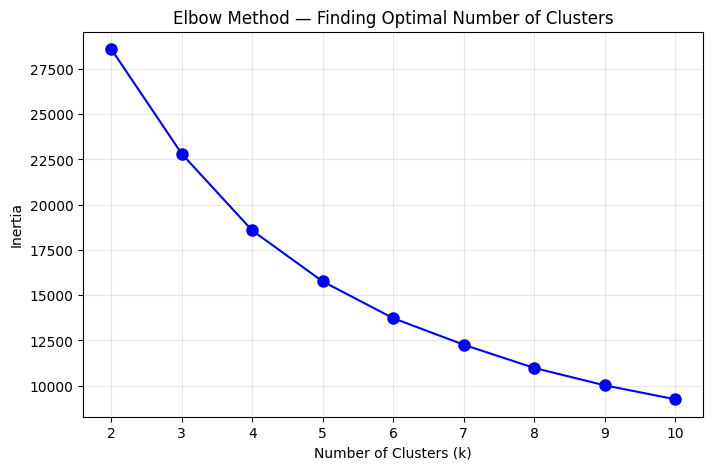

In [19]:
# Cell 17 - Elbow Method to find optimal clusters
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Optimal Number of Clusters')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

PCA explained variance: [0.26478117 0.22730109]
Total variance captured: 49.2%


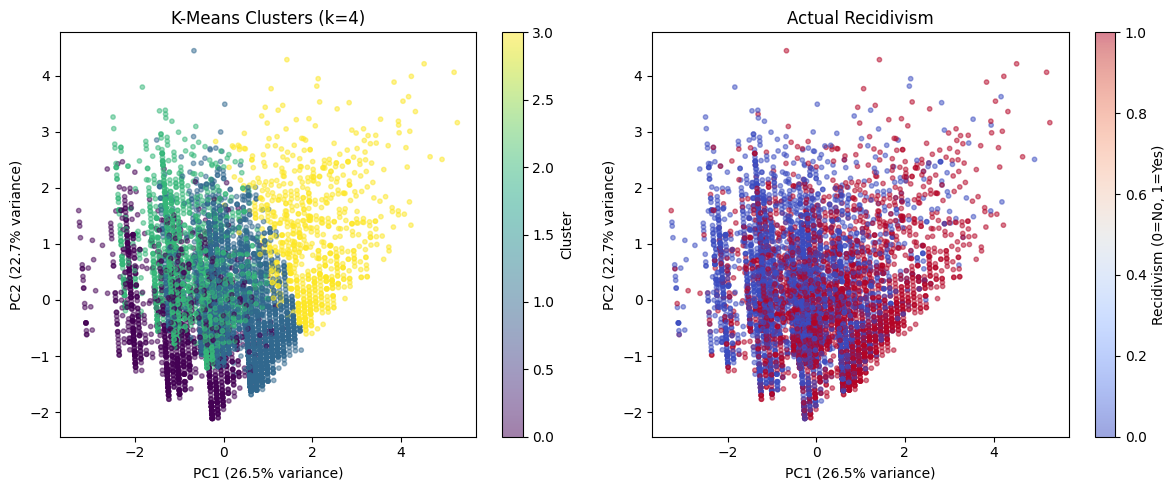

In [20]:
# Cell 18 - K-Means Clustering + PCA Visualization
# Train K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Reduce to 2D with PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA explained variance: {pca.explained_variance_ratio_}")
print(f"Total variance captured: {pca.explained_variance_ratio_.sum():.1%}")

# Plot clusters
plt.figure(figsize=(12, 5))

# Plot 1 - Clusters
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=clusters, cmap='viridis', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means Clusters (k=4)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')

# Plot 2 - Actual Recidivism
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                       c=y, cmap='coolwarm', alpha=0.5, s=10)
plt.colorbar(scatter2, label='Recidivism (0=No, 1=Yes)')
plt.title('Actual Recidivism')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')

plt.tight_layout()
plt.show()

## 🔍 Unsupervised Learning — What Did the Data Find on Its Own?

### PCA — Reducing to 2 Dimensions
PCA compressed our 5 features into 2 dimensions for visualization:
- **PC1 captures 26.5%** of the variance
- **PC2 captures 22.7%** of the variance
- **Total: 49.2%** — we kept about half the information

This means the 2D plot gives us a reasonable but incomplete picture 
of the data structure.

### K-Means Clusters (left chart)
The algorithm found 4 natural groups in the data without being 
told anything about recidivism. The clusters are fairly well 
separated, especially along PC1 (horizontal axis).

### Actual Recidivism (right chart)
- **Red dots** = people who DID reoffend
- **Blue dots** = people who did NOT reoffend

### 🚨 Key Observation:
Compare the two charts side by side:
- The **clusters do NOT cleanly map to recidivism**
- Red and blue dots are heavily mixed throughout all clusters
- This tells us that the natural groupings in the data are NOT 
  primarily driven by recidivism behavior

### What IS driving the clusters then?
Most likely **age and prior convictions** since they were the 
strongest features. Let's investigate next!

In [21]:
# Cell 19 - Cluster Profiles
df_cluster = X_unsup.copy()
df_cluster['cluster'] = clusters
df_cluster['recidivism'] = y.values

# Decode categorical variables back for readability
df_cluster['sex'] = df_cluster['sex'].map({1: 'Male', 0: 'Female'})
df_cluster['c_charge_degree'] = df_cluster['c_charge_degree'].map({1: 'Felony', 0: 'Misdemeanor'})

# Profile each cluster
profile = df_cluster.groupby('cluster').agg({
    'age': 'mean',
    'priors_count': 'mean',
    'recidivism': 'mean',
    'cluster': 'count'
}).rename(columns={'cluster': 'count'}).round(2)

print("=== Cluster Profiles ===")
print(profile.to_string())

=== Cluster Profiles ===
           age  priors_count  recidivism  count
cluster                                        
0        34.70          1.88        0.35   1360
1        32.68          2.25        0.46   3196
2        36.13          2.07        0.39   1879
3        40.63         14.65        0.72    779


## 👥 Cluster Profiles — Who is in Each Group?

| Cluster | Avg Age | Avg Priors | Recidivism Rate | Count |
|---|---|---|---|---|
| 0 | 34.7 | 1.88 | 35% | 1,360 |
| 1 | 32.7 | 2.25 | 46% | 3,196 |
| 2 | 36.1 | 2.07 | 39% | 1,879 |
| 3 | 40.6 | 14.65 | 72% | 779 |

### Plain English — What Each Cluster Represents:

**Cluster 0 — Lower Risk Young Adults (35% recidivism)**
Relatively young (34.7), very few priors (1.88).
These are people with minimal criminal history.

**Cluster 1 — Moderate Risk Young Adults (46% recidivism)**
Youngest group (32.7), slightly more priors (2.25).
The largest group at 3,196 people — the "average" case.

**Cluster 2 — Moderate Risk Middle Aged (39% recidivism)**
Slightly older (36.1), similar priors to Cluster 0.
Similar to Cluster 0 but older.

**Cluster 3 — Very High Risk Repeat Offenders (72% recidivism!)**
Oldest group (40.6) but by far the most priors (14.65!).
Only 779 people but 72% recidivism rate — these are 
serious repeat offenders with extensive criminal histories.

### 🚨 Key Findings:

**Prior convictions is the defining factor:**
The jump from ~2 priors (Clusters 0-2) to 14.65 priors (Cluster 3) 
is dramatic — and it perfectly explains the recidivism rate jump 
from ~35-46% to 72%.

**Age alone does not explain recidivism:**
Cluster 3 is actually the OLDEST group yet has the highest 
recidivism — because their prior conviction count is so high 
it overwhelms the age effect.

**The data found this on its own — with no labels!**
We never told the algorithm about recidivism. Yet it naturally 
separated out the high-risk repeat offender group (Cluster 3) 
just by finding patterns in age and priors. This validates 
that our supervised model was learning real signal.

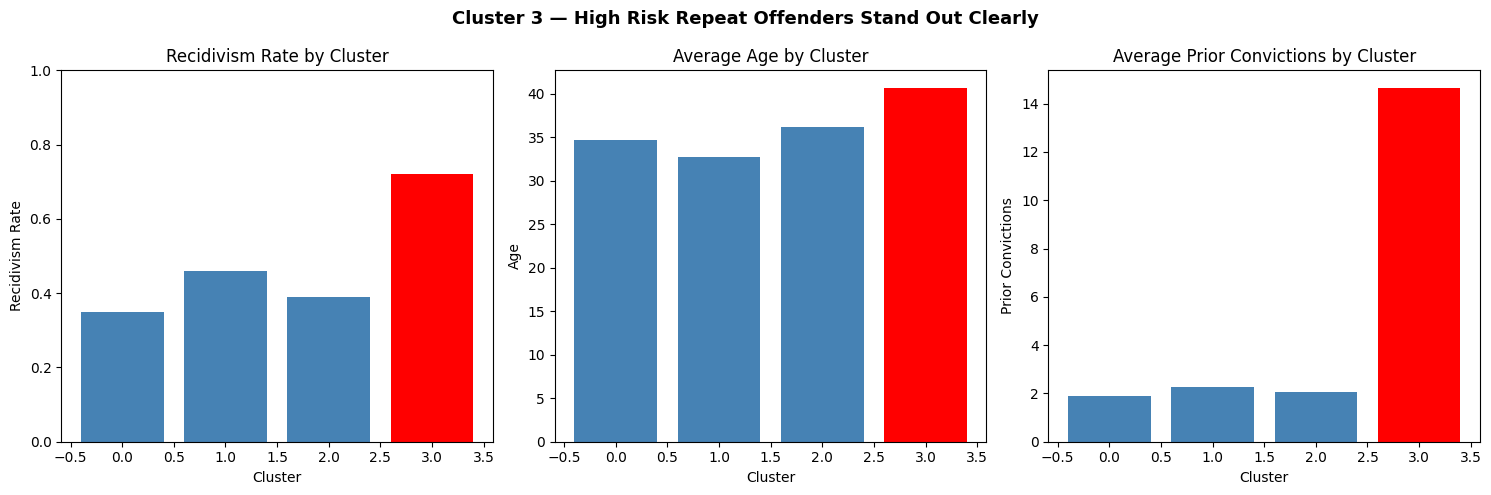

In [23]:
# Cell 20 - Cluster Profile Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Recidivism rate by cluster
axes[0].bar(profile.index, profile['recidivism'], 
            color=['steelblue', 'steelblue', 'steelblue', 'red'])
axes[0].set_title('Recidivism Rate by Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Recidivism Rate')
axes[0].set_ylim(0, 1)

# Average age by cluster
axes[1].bar(profile.index, profile['age'],
            color=['steelblue', 'steelblue', 'steelblue', 'red'])
axes[1].set_title('Average Age by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Age')

# Average priors by cluster
axes[2].bar(profile.index, profile['priors_count'],
            color=['steelblue', 'steelblue', 'steelblue', 'red'])
axes[2].set_title('Average Prior Convictions by Cluster')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Prior Convictions')

plt.suptitle('Cluster 3 — High Risk Repeat Offenders Stand Out Clearly', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 🏁 Conclusion — What Did We Learn?

## Technical Summary
In this notebook we analyzed the COMPAS recidivism dataset using both 
supervised and unsupervised machine learning techniques.

| Analysis | Key Finding |
|---|---|
| Random Forest Model | 64.5% accuracy — better than chance but not reliable enough for real decisions |
| Cross Validation | 62.1% mean accuracy — consistent and stable model |
| Feature Importance | Age (54.5%) and prior convictions (30.8%) drive predictions most |
| SHAP Values | Race influences individual predictions despite low overall importance |
| Bias Analysis | African-Americans wrongly labeled high risk at nearly double the rate of Caucasians |
| Removing Race | Did NOT fix bias — proxy variables carry the same discrimination |
| Unsupervised Learning | Data naturally found 4 groups — repeat offenders (Cluster 3) stand out with 72% recidivism |

## The Bigger Picture
This project demonstrates three things that go beyond technical skills:

**1. Accuracy is not enough**
A model can be statistically reasonable (62-64% accurate) while still 
being deeply unfair to specific groups. In criminal justice, fairness 
must be evaluated alongside accuracy.

**2. You cannot fix biased data by removing sensitive variables**
Removing race from the model had almost no effect on the bias against 
African-Americans. The discrimination was encoded in other variables 
like age and prior convictions through decades of systemic inequality.

**3. Unsupervised learning validates supervised findings**
Without any labels, K-Means naturally identified the same high-risk 
group (repeat offenders with 14+ priors) that the supervised model 
flagged. This gives us confidence that the model is learning real 
patterns — not just noise.

## Final Thought
Algorithms like COMPAS are already being used in real courtrooms 
across the United States to influence bail, sentencing, and parole 
decisions. This analysis shows that without careful human oversight, 
domain expertise, and bias auditing — these tools can silently 
perpetuate and amplify systemic injustice at scale.

The goal of this project is not to condemn algorithmic tools in 
criminal justice — but to demonstrate that **responsible AI requires 
both technical skill and domain wisdom**. Neither alone is sufficient.

---
*Dataset: COMPAS Recidivism Dataset — ProPublica (2016)*
*Tools: Python, Scikit-learn, SHAP, Pandas, Matplotlib, Seaborn*
*Author: Marzieh Farzamfar*